# Performance Metrics

## Recap data preprocessing

### Missing data

- Representations
- Locating
- Dropping
- Imputing

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/missing_data_2.png' width=300 style='margin:auto'> 

### Scaling

- Standardizing - centering around a **mean of 0** with an **std of 1**
- Normalizing (with `MinMaxScaler`) - scaling data to be **between 0 and 1**
- Robust Scaling - centering around a **median of 0** with the **IQR (Interquartile Range) of 1**

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/scaling.png' width=400 style='margin:auto'> 

### Outliers

- Detecting
- Interpreting
- Dropping
- Preserving

<img align = 'center' src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/outliers2.png'  width=300>

### Encoding

- Categorical
- Ordinal
- Label Encoding
- One Hot Encoding

<img align='center' src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/label_encoding.png'  width=200>

### Balancing

- Oversampling
- Undersampling
- SMOTE
- ⚠️ Avoiding leakage

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/balancing.png'  width=1200>

### Discretizing

- Continuous to categorical/ordinal
- Regression to Classification
- Binning a continuous value

### Feature Engineering

- Creating features with domain knowledge

### Feature Selection

- Garbage in, garbage out
- Feature permutation
- Correlation matrix


## Today's Plan
1. **New model type** - K-Nearest Neighbors 
2. Model lifecycle
2. Baseline score
3. Regression Metrics
4. Classification Metrics
5. Error analysis


In [2]:
import pandas as pd

data = pd.read_csv("https://wagon-public-datasets.s3.amazonaws.com/insurance_ML3.csv")
data.drop(columns=['sex', 'region'], inplace=True)

# 1. K-Nearest Neighbors

## K-Nearest Neighbors
K-Nearest Neighbors (KNN) is a non-linear, distance based model capable of solving both Regression and Classification tasks.

* Looks at `K` closest samples to make a prediction
* Up to us to determine `K` (hyperparameter)
* [Sklearn `neighbors` API](https://scikit-learn.org/stable/modules/classes.html?highlight=neighbors#module-sklearn.neighbors)

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/KNN_Lecture/KNN_New_Sample.png' width=500 style='margin:auto'> 



### Calculate distance from sample
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/KNN_Lecture/KNN_Distances.png' width=500 style='margin:auto'> 

### Choose K closest samples for a prediction
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/KNN_Lecture/KNN_Class.png' width=500 style='margin:auto'> 

### Majority vote for classification
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/KNN_Lecture/KNN_Reg.png' width=500 style='margin:auto'> 

### Average value for regression
<img src='img/machine-learning/KNN_regression3.png' width=500 style='margin:auto'> 

### Choosing k
The optimal 𝑘 will vary from dataset to dataset.

- Lower k values, less observations to use to make a prediction, prone to overfitting
- Higher k values, signal can be diluted, prone to underfitting

### Changing K might change prediction
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/KNN_Lecture/KNN_Change.png' width=500 style='margin:auto'> 

### You can use KNN as a:

- Regressor with [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)
- Classifier with [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

And more! ⭐

- Similarity detection and clustering with [NearestNeighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html) - _more on this during Unsupervised Learning!_
- Imputing missing data with [KNNImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html)

In [4]:
import pandas as pd

data = pd.read_csv("https://wagon-public-datasets.s3.amazonaws.com/insurance_ML3.csv")
data.drop(columns=['sex', 'region'], inplace=True)

# 2. Model lifecycle

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/model_lifecycle.png' width=600 style='margin:auto'>


🧐 So how do we know if the current idea is better than a previous iteration? 🧐

### Evaluation metrics
Evaluation metrics are used to measure how well a machine learning model can perform a task.

🚨 A single metric will only tell one side of the story. Ensure you investigate a model's effectiveness from multiple angles 🚨

# 3. Baseline Score

When evaluating a machine learning pipeline, you need a basis for comparison. A baseline score utilizes very simple strategies for prediction:

- **Classification**: Predicts a random or most frequent class
- **Regression**: Predicts a central tendency measure e.g. mean, median or mode


Examples will be shown on the following [dataset](https://wagon-public-datasets.s3.amazonaws.com/insurance_ML3.csv).

In [5]:
data.head()

,age,bmi,children,smoker,charges,price_range
0,19,27.900,0,True,16884.92400,expensive
1,18,33.770,1,False,1725.55230,cheap
2,28,33.000,3,False,4449.46200,cheap
3,33,22.705,0,False,21984.47061,expensive
4,32,28.880,0,False,3866.85520,cheap


## 💻 Regression baseline

Using the [dummy estimators](https://scikit-learn.org/stable/modules/classes.html?highlight=dummy#module-sklearn.dummy) from `sklearn`.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

# Prepare X and y
X = data[['age','bmi','children','smoker']]
y = data['charges']


X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state = 6) # Holdout


baseline_model = DummyRegressor(strategy="mean") # Baseline
baseline_model.fit(X_train, y_train) # Calculate value for stratgy
baseline_model.score(X_test, y_test) # Score model based on consistently predicting the strategy

-0.001233635021205659

In [7]:
model = LinearRegression().fit(X_train, y_train) # instantiate and fit model

model.score(X_test, y_test) # Score model

0.773425820295562

🧐 Using a dummy model at the start allows us to move rapidly through each step of pipeline construction. This gives us the ability to identify obstacles downstream more quickly. 🧐

# 4. Regression Metrics

### Regression metrics
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/regression_metric_basic.png' width=600 style='margin:auto'>


There are lots of ways to measure the difference between two points...

## Mean Squared Error (MSE)

Mean of the squared differences between ground truth and predicted values.

- Useful to penalize large errors
- No sense of direction
- Not expressed in the same units as the target
- Very sensitive to outliers

$$ \large \text{MSE} = {\frac{1}{n} \sum_{i = 1}^{n} (y_i - \hat y_i)^2} $$


<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/MSE_boxes_explaination.png' width=600 style='margin:auto'>

👉 Use MSE when:
- Larger errors have a disproportionally bigger impact, hence should be more penalized
  - Example: clinical trials, where an error of 4mg can be *more than twice as bad* as an error of 2mg
- Direction and unit of error does not matter
- Comparing the sensitivity of different models/methods to large errors

## Root Mean squared error (RMSE)

Square root of the Mean Square Error.


$$\large \text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i = 1}^{n} (y_i - \hat y_i)^2 } $$


👉 Use RMSE when you want the MSE to be represented in the unit of the target, making it more interpretable

## Mean absolute error

The mean of the absolute differences between true values and predicted values.

- Less sensitive to outliers

$$\large \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y_i}|$$


👉 Use MAE when errors can be penalized proportionally to their size
  - Example: weather forecast, where an error of 4 degrees is simply *twice as bad* as an error of 2 degrees

## Max Error

The biggest error made by the model when predicting.

$$\large ME = \max_{i=1}^{n} |y_i - \hat{y_i}|$$

👉 Use Max Error when you want to limit the magnitude of the errors. 
  - Example: temperature management for a piece of equipment that can overheat *maximum* 2 degrees

## Coefficient of determination $R^2$
The proportion of the variance in the dependent variables that is explained by the independent variables. 

- Typically ranges from 0 to 1
- Optimal score of 1

$$\large R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y_i})^2}{\sum_{i=1}^{n} (y_i - \overline{y})^2}$$


👉 Use $R^2$ when:
- The unit of the error is not important
- You want to compare between different datasets

## 💻 Comparing metrics

In [8]:
y_pred = model.predict(X)

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error
import math

mse = mean_squared_error(y, y_pred)

rmse = math.sqrt(mse)

mae = mean_absolute_error(y, y_pred)

rsquared = r2_score(y, y_pred)

max_error = max_error(y, y_pred)

print('MSE =', round(mse, 2))
print('RMSE =', round(rmse, 2))
print('MAE =', round(mae, 2))
print('R2 =', round(rsquared, 2))
print('Max Error =', round(max_error, 2))

MSE = 36776200.68
RMSE = 6064.34
MAE = 4234.0
R2 = 0.75
Max Error = 29184.77


### 💻 Metrics during Cross-validation
We can specify the scoring metric with the `scoring` parameter of `cross_validate`
- A metric of choice can be specified directly with algorithms.
- If `scoring` is not set, the model's default scoring metric (using model's `.score()` method) is used.

In [10]:
from sklearn.model_selection import cross_validate
# 5-Fold Cross validate model
model = LinearRegression()
cv_results = cross_validate(model, X, y, cv=5,
                            scoring=['max_error',
                                     'r2',
                                     'neg_mean_absolute_error',
                                     'neg_mean_squared_error']
                           )
pd.DataFrame(cv_results) # Cross validation output

,fit_time,score_time,test_max_error,test_r2,test_neg_mean_absolute_error,test_neg_mean_squared_error
0,0.002384,0.002078,-24053.301788,0.760959,-4210.447467,-3.714635e+07
1,0.002002,0.001650,-23060.600919,0.708823,-4219.303638,-3.781926e+07
2,0.001276,0.002189,-26395.712047,0.776167,-4026.911043,-3.285122e+07
3,0.001116,0.001249,-23282.860901,0.731409,-4297.280431,-3.987217e+07
4,0.000896,0.001523,-29700.376643,0.756647,-4218.673537,-3.696269e+07


In [11]:
cv_results['test_r2'].mean() # Cross validation results

0.7468009563921238

To check all the available scoring metrics type 👉 [`sklearn.metrics.SCORERS.keys()` documentation](https://scikit-learn.org/stable/modules/model_evaluation.html).

Choosing a metric:

👉 Use **MSE** when you need to penalize large errors more strictly than small ones.

👉 Use **RMSE** when you need to penalize large errors, but see it in the unit of the target.

👉 Use **MAE** when all errors, large or small, have equal importance and you need easily interpretable results

👉 Use **Max Error** when you want to limit the magnitude of the errors.

👉 Use **R<sup>2</sup>** as a general "goodness-of-fit" metric to compare performance across changes to models and the data

There are many more regression metrics that you can check out in the [documentation](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics).

# 5. Classification Metrics

Two ways for a model to have a correct prediction:
- **True Positive-** Correctly identifying a positive sample
 - Predicted ✅
 - Actual ✅
- **True Negative-** Correctly identifying a negative sample
 - Predicted ❌
 - Actual ❌

Two ways a model can have an incorrect prediction:
- **False Positive-** Incorrectly identifying a positive sample
 - Predicted ✅
 - Actual ❌
- **False Negative-** Incorrectly identifying a negative sample
 - Predicted ❌
 - Actual ✅

## Confusion Matrix

We grade and tally our predictions in a confusion matrix.


<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/confusion_matrix_editable.png' width=500 style='margin:auto'> 

In [12]:
y_test = [0, 1, 0, 0, 1, 0, 1, 1, 0, 1] # actual truths
preds = [0, 0, 0, 0, 1, 1, 1, 1, 1, 1] # predictions

results_df = pd.DataFrame({"actual": y_test,
                           "predicted": preds}) #Store results in a dataframe

confusion_matrix = pd.crosstab(index= results_df['actual'],
                               columns = results_df['predicted'])

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/crosstab_example.png' width=100 style='margin:auto'> 

[Pandas `crosstab` documentation](https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html)

We're building a model to predict the likelihood of a student passing an exam. 

Let's try and grade a model's predictions💪

## Predicted labels
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/model_prediction_performance.png' width=500 style='margin:auto'> 

## Actual labels
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/actual_performance.png' width=500 style='margin:auto'> 

## Grading labels

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/classification_grading_steps_annotated.png' width=5000 style='margin:auto'> 


<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/classification_graded_with_confusion_matrix.png' width=1000 style='margin:auto'> 

## Accuracy

Sum of the correct predictions divided by the sum of the overall number of predictions

$\large accuracy = \frac{TP + TN}{TP + TN + FP + FN} $

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/confusion_matrix_worked_example.png' width=500 style='margin:auto'> 

$\large 0.7 = \frac{4 + 3}{4 + 3 + 2 + 1} $

👉 [Sklearn's `accuracy_score` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score)

🧐 But what about the model's mistakes? 🧐

🧐 What would the accuracy be for this example? 🧐

$\large accuracy = \frac{TP + TN}{TP + TN + FP + FN} $

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/ac91recall10.png' width=300 style='margin:auto'> 


$\large 0.91 = \frac{1 + 90}{0 + 90 + 1 + 9} $

Anything strange about the performance?

🧐 Looks like our model almost always predicts ❌ 🧐

🚨 Using accuracy **alone** can give overly confident scores, especially when dealing with imbalanced datasets 🚨

👉 Use $accuracy$ when:
- Target classes are balanced
- Prediction of each class is equally important

## Recall

Measures the ability of the model to detect occurrences of a class.

$\large recall = \frac{TP}{TP + FN} $


$\large 0.8 = \frac{4}{4 + 1} $

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/recall-annotated.png' width=500 style='margin:auto'> 


👉 [Sklearn's `recall_score` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score)

Looking at the example from before, what is the $ recall $ ❓
    
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/ac91recall10.png' width=300 style='margin:auto'>

$\large 0.1 = \frac{1}{9 + 1} $

👎 This model is really bad at identifying the Positive class.

👉 Use $recall$ when:
- It is important to identify as many occurrences of a class as possible, reducing false negatives but potentially increasing false positives

- You don't want to miss any positive classes

- E.g. Detecting fraudulent transactions, cases of a novel disease or potential sales leads

🧐 When **could** this metric alone be problematic? 🧐

$\large recall = \frac{TP}{TP + FN} $


$\large 0.9 = \frac{27}{27 + 3} $


<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/recall_warning.png' width=500 style='margin:auto'> 


🧐 We could get too many false alarms 🧐

* These results could be great for identifying fraudulent payments at a bank 
* But could also be terrible for a smoke alarm

## Precision

Measures the ability of a model to avoid false alarms for a class, or the confidence of a model when predicting a specific class.

$\large precision = \frac{TP}{TP + FP} $

$\large 0.67 = \frac{4}{4 + 2} $


<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/precision-annotated.png' width=500 style='margin:auto'> 

👉 [Sklearn's `precision_score` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score)

👉 Use $precision$ when:
- It is important to be correct when identifying a class, reducing false positives but potentially increasing false negatives

- E.g. Targeted advertising, food and drug safety (you'd like the model to be *really confident* when classifying a drug as safe)

🧐 When could using precision alone be problematic? 🧐

$\large precision = \frac{TP}{TP + FP} $

$\large 0.89 = \frac{356}{356 + 44} $

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/precision_problem.png' width=500 style='margin:auto'> 


$\large recall = \frac{TP}{TP + FN} $


$\large 0.28 = \frac{356}{356 + 900} $

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/precision_problem.png' width=500 style='margin:auto'> 


## $F_1\ score$

A combination of precision and recall into a single metric.

$\large F_1 = 2 ·\frac{precision \times recall}{precision + recall} $

$\large 0.73 = 2 ·\frac{0.67 \times 0.8}{0.67 + 0.8} $


<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/confusion_matrix_worked_example.png' width=500 style='margin:auto'> 


👉 [Sklearn's `f1_score` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score)

- Also known as the harmonic mean of precision and recall
- It will be influenced more by the lower of the two values

👉 Use $F_1\ score$ when you want:
- A general metric to compare across models and datasets
- Combine the Precision/Recall tradeoff in a single metric

## 💻 Comparing metrics

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = [0, 1, 0, 0, 1, 0, 1, 1, 0, 1]
y_pred = [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]

print('Accuracy =', round(accuracy_score(y_true, y_pred), 2)) # Accuracy

print('Precision =', round(precision_score(y_true, y_pred), 2)) # Precision

print('Recall =', round(recall_score(y_true, y_pred), 2)) # Recall

print('F1 score =', round(f1_score(y_true, y_pred), 2)) # F1 score

Accuracy = 0.7
Precision = 0.67
Recall = 0.8
F1 score = 0.73


## `classification_report`

Generates a report containing `precision`, `recall`, and `f1-score`. `support` is the class count.

- `macro avg` is the average score across classes
- `weighted` calculates score weighted by class balance ratio

In [14]:
from sklearn.metrics import classification_report

target_names = ['class 0', 'class 1']

print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.75      0.60      0.67         5
     class 1       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



## Different applications, different metrics
- We build models for specific tasks, each task will have a desired outcome 
- We must pick a metric that suits the task

🧐 We're building a model to detect the safety of seatbelts. What metric should we optimize for? 🧐

* Seat belt safe = 1
* Seat belt faulty = 0

* What's the cost of an incorrect prediction?

* Is it worse to release a faulty seatbelt, or to throw away a safe seatbelt?

* Optimize for **precision**
* We'd rather prevent injury (reduce false positives), and we're okay with the cost of throwing away a "maybe" safe seatbelt (false negatives)

🧐 We can optimize for **<ins>a</ins>** metric by adjusting probability thresholds 🧐

## The Precision-Recall Tradeoff
- There is an inverse relationship between precision and recall
- Typically, we will trade one off against the other

Let's go back to our exam predictions...

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/performance_example_threshold_05.png' width=1000 style='margin:auto'> 


<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/0.2_threshold_fixed.png' width=1000 style='margin:auto'> 

Recall has gone up

Precision has gone down

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/0503_higher_probability_threshold.png' width=1000 style='margin:auto'> 


Precision has gone up

Recall has gone down

## 🖥 `precision_recall_curve`

The `precision_recall_curve` lets us compare precision and recall across a variety of thresholds. 

We can use this to find a threshold that guarantees a score for one metric whilst maintaining a minimum score for the other.

Let's put it into practice in a business application...

We are working at an insurance company trying to predict whether a policy will be expensive or not. Our boss has informed us that our previous model gave out cheaper than expected policies to customers, causing the company to lose money.

They want at least 80% of the **expensive policy customers to be identified**.

Since that's the class of focus, let's consider `expensive` policy holders as class `1`

❓ Which metric should we optimize for?

❓ How would we adjust our thresholds for our next iteration?

ℹ️ We should optimize for $ recall $ (Do you understand why? 🤔)

ℹ️ We should **lower** the threshold to be classified as a `1` (expensive policy holder)

🧐 Could there be any repercussions to this? 🧐

Customers who would normally get cheap policies, may get mis-sold expensive policies!

First, let's encode the target into `0` and `1`.

❓ Which sklearn encoder you would you use in this case?

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(data['price_range'])

print(le.classes_) # to check the order of classes that will be encoded

data['price_range_encoded'] = le.transform(data['price_range'])
data[['price_range', 'price_range_encoded']].head()

['cheap' 'expensive']


,price_range,price_range_encoded
0,expensive,1
1,cheap,0
2,cheap,0
3,expensive,1
4,cheap,0


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

model = LogisticRegression()

# Predict class probabilties
data['proba_cheap'], data['proba_expensive'] =cross_val_predict(model,
                                                                X,
                                                                data['price_range_encoded'],
                                                                cv=5,
                                                                method='predict_proba').T

# precision recall data
precision, recall, threshold = precision_recall_curve(data['price_range_encoded'],
                                                      data['proba_expensive'])

print(f'precision- {precision[:5]}')
print(f'recall- {recall[:5]}')
print(f'threshold- {threshold[:5]}')

precision- [0.31390135 0.31413613 0.31437126 0.31460674 0.31484258]
recall- [1. 1. 1. 1. 1.]
threshold- [0.02341412 0.02358978 0.02403223 0.02427324 0.02464116]


In [17]:
scores = pd.DataFrame({'threshold':threshold,
                       'precision': precision[:-1],
                       'recall':recall[:-1]}) # Store in a dataframe
scores

,threshold,precision,recall
0,0.023414,0.313901,1.000000
1,0.023590,0.314136,1.000000
2,0.024032,0.314371,1.000000
3,0.024273,0.314607,1.000000
4,0.024641,0.314843,1.000000
...,...,...,...
1332,0.995472,1.000000,0.011905
1333,0.995481,1.000000,0.009524
1334,0.995697,1.000000,0.007143
1335,0.995876,1.000000,0.004762


## Plot the tradeoff

Text(0.5, 0, 'recall')

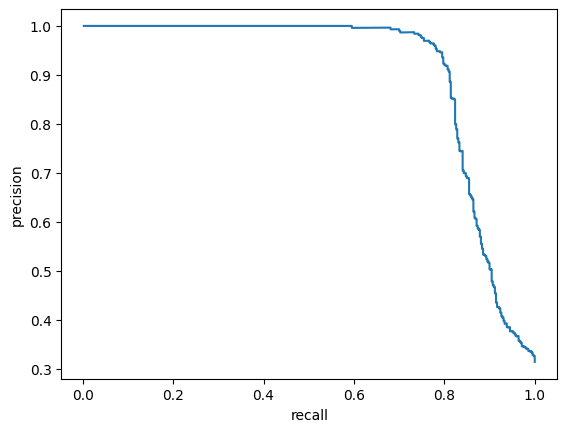

In [18]:
plt.plot(scores['recall'],scores['precision'])
plt.ylabel('precision')
plt.xlabel('recall')

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/precision_recall_tradeoff_annotated.png' width=80000>

#### Find the threshold that guarantees a 0.8 recall score

In [19]:
scores[scores['recall'] >= 0.8].threshold.max()

0.3055393000252563

We'll now update our threshold for our model using a custom prediction wrapper

In [20]:
model = LogisticRegression()
model.fit(X, data['price_range_encoded'])

def custom_predict(X, custom_threshold):
    probs = model.predict_proba(X) # Get likelihood of each sample being classified as 0 or 1
    expensive_probs = probs[:, 1] # Only keep expensive likelihoods (1)
    return (expensive_probs > custom_threshold).astype(int) # Boolean outcome converted to 0 or 1


updated_preds = custom_predict(X=X, custom_threshold=0.305539) # Update predictions

print("Recall:", recall_score(data['price_range_encoded'], updated_preds)) # Rerun recall
print("Precision:", precision_score(data['price_range_encoded'], updated_preds)) # Rerun precision
print("F1 Score:", f1_score(data['price_range_encoded'], updated_preds)) # Rerun f1


Recall: 0.8071428571428572
Precision: 0.9287671232876712
F1 Score: 0.8636942675159236


We've identifed that the optimum threshold for the task requiring 80% recall was ~0.31 and updated our decision thresholds accordingly 💪

## ROC-AUC (Receiver Operating Characteristic-Area Under Curve)

Similar to the Precision-Recall curve, the ROC curve summarizes the ability of the model to trade-off between two metrics across different thresholds.


$True\;positive\;rate = sensitivity\;= recall = \frac{TP}{TP + FN}$

$False\;positive\;rate = (1-specificity) = \frac{FP}{FP + TN}$ 


<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/ROC.png' width=300>

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/ROC_explain_TPR=FPR.png' width=400>

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/ROC_explain_good_ratio.png' width=400>

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/ROC_explain_sharp_decline.png' width=400>

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/ROC_explain_TPR0FPR0.png' width=400>



### AUC (Area Under Curve)

The AUC gives an indication of overall model performance.

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/AUC.png' width=400>

### Comparing models
The larger the AUC, the greater the overall general performance.
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/AUC_2_models.png' width=400>

* Unlike F1, recall, precision and accuracy- AUC is not dependent on a chosen threshold 
* This makes it a great metric for measuring a model's general performance 💪

### In Sklearn...

In [21]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Extract associated metrics and thresholds
fpr, tpr, thresholds = roc_curve(data['price_range_encoded'], data['proba_expensive'])

# Compute AUC score
auc_score = roc_auc_score(y_true, y_pred)
auc_score

0.7000000000000001

👉 [Sklearn `roc_auc_score` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#sklearn.metrics.roc_auc_score)

👉 [Sklearn `roc_curve` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html#sklearn.metrics.roc_curve)

### Summary - Classification Metrics

<table>
<thead>
  <tr style='text-align: center;'>
    <th>Metric</th>
    <th>Use when...</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td>Accuracy</td>
    <td>You want to know if your model predicts well overall, without focus on a particular class</td>
  </tr>
  <tr>
    <td>Recall</td>
    <td>You want to capture as many occurrences of a class, even if you capture wrong ones too</td>
  </tr>
  <tr>
    <td>Precision</td>
    <td>You want to be really sure that you predicted the right class when you predict it</td>
  </tr>
  <tr>
    <td>F1 Score</td>
    <td>You want a harmonic measurement of precision and recall; good for comparing across models and datasets</td>
  </tr>
  <tr>
    <td>ROC-AUC Score</td>
    <td>General model robustness metric, showing how well the model is able to distinguish between two classes across all thresholds.</td>
  </tr>
</tbody>
</table>

# 6. Error analysis

### Error analysis
An iterative process for identifying common themes within our model's mistakes
- Do specific cohorts within our X data perform better or worse than others?
- Is one class consistently identified better than others?
- Are some errors so large they drag overall performance down?

These questions can lead you to more data collection or enhanced feature engineering.

🚨 Remember, each metric tells a **specific** story, but not the **full** story 🚨

## Your turn! 🚀